In [1]:
# --- Imports / environment ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sawtooth

In [2]:
BUF_LEN = 131072
DAC_SR = 8e9
DAC_AMP = 2**15-1

t_dac = np.arange(BUF_LEN, dtype=float) / DAC_SR

In [3]:
def make_saw(freq_hz: float, amp: float = 1 * DAC_AMP) -> np.ndarray:
    if sawtooth is None:
        raise RuntimeError("scipy is not available; sawtooth() requires scipy.signal")
    y = amp * sawtooth(2*np.pi*freq_hz*(t_dac))
    return np.int16(y)

def plot_signal(sig: np.ndarray, sr_hz: float, title: str, n: int = 4096/2):
    tt = np.arange(min(len(sig), n)) / sr_hz
    plt.figure(figsize=(11, 4))
    plt.plot(tt * 1e6, sig[:len(tt)])
    plt.title(title)
    plt.xlabel("Time [µs]")
    plt.ylabel("Amplitude [LSB]")
    plt.grid(alpha=0.3)
    plt.tight_layout()

AMP 32767


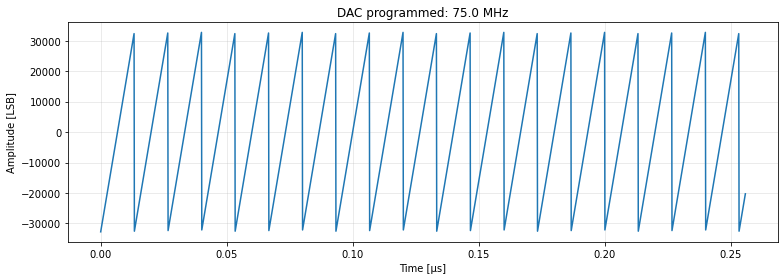

In [4]:
# Program a waveform
freq_hz = 75e6-1
amp = 1* DAC_AMP
print("AMP", amp)

signal = make_saw(freq_hz, amp=amp)

plot_signal(signal, DAC_SR, f"DAC programmed: {freq_hz/1e6:.1f} MHz")

In [38]:
# read transfer function data
def load_transfer_function_csv(csv_path: str):

    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
    f_hz = data[:, 0] * 1e9
    s21_db = data[:, 1]
    H_mag = 10 ** ((s21_db-30) / 20.0)
    return f_hz, H_mag

# interplate the transfer function into the target frequency aixs
def interp_transfer_to_rfft_bins(f_tf_hz: np.ndarray,
                                 H_tf: np.ndarray,
                                 n: int,
                                 fs: float) -> np.ndarray:

    f_bins = np.fft.rfftfreq(n, d=1.0/fs)
    H_bins = np.interp(f_bins, f_tf_hz, H_tf, left=H_tf[0], right=H_tf[-1])
    return f_bins, H_bins

# inverse the transfer function
# define a factor reg, if reg is large, 
# means the inverse will give less gain in low frequency regime
def regularized_inverse(H: np.ndarray, reg: float = 0.02, floor: float = 1e-3) -> np.ndarray:

    H_abs = np.abs(H)
    H_abs = np.maximum(H_abs, floor)
    return np.conj(H) / (H_abs**2 + reg**2)


def normalize_to_dac(x: np.ndarray, amp_limit: float) -> np.ndarray:
    peak = np.max(np.abs(x))
    if peak == 0:
        return x.copy()
    return x * (amp_limit / peak)

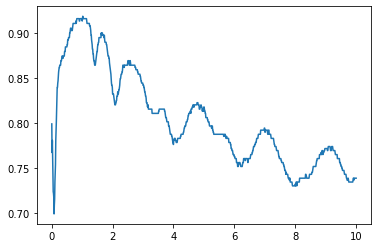

In [39]:
f, H_mag = load_transfer_function_csv("S21_digitized_native.csv");
plt.plot(f/1e9,H_mag)

f_bins,H_bins = interp_transfer_to_rfft_bins(
        f_tf_hz=f,
        H_tf=H_mag,
        n=len(signal),
        fs=DAC_SR
    )

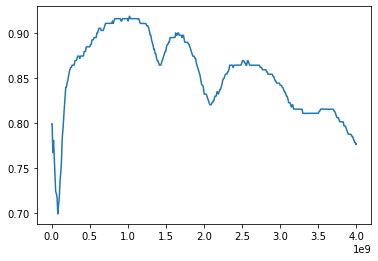

In [40]:
plt.plot(f_bins,H_bins)

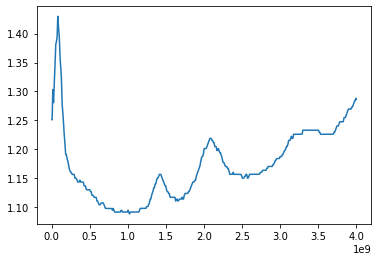

In [44]:
H_inv = regularized_inverse(H_bins, reg=0)
plt.plot(f_bins,H_inv)

In [47]:
Y = np.fft.rfft(signal)
X_pre = Y * H_inv 
x_pre = np.fft.irfft(X_pre, n=len(signal))

x_pre = normalize_to_dac(x_pre, amp_limit=DAC_AMP)


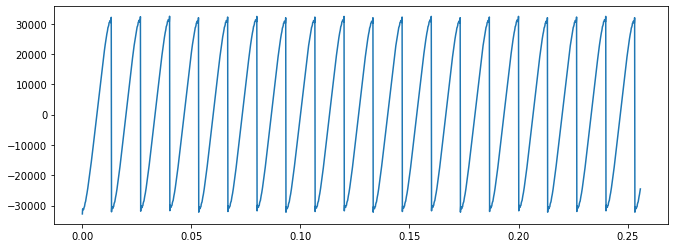

In [52]:
plt.figure(figsize=(11, 4))
plt.plot(t_dac[:2048]*1e6,x_pre[:2048])